In [ ]:
import zipfile

with zipfile.ZipFile("student.zip", 'r') as zip_ref:
  zip_ref.extractall("student_data")
print("Inner student.zip extracted successfully")

Inner student.zip extracted successfully


In [ ]:
import os
os.listdir("student_data")


['student-merge.R', 'student-mat.csv', 'student.txt', 'student-por.csv']

In [ ]:
import pandas as pd

data = pd.read_csv("student_data/student-mat.csv", sep=";")
# Create 'attendance' column from 'absences' before attempting to use it
data['attendance'] = 100 - data['absences']
# Now, select the desired columns and display their head
print(data[['attendance', 'studytime', 'G1', 'G2', 'G3']].head())

   attendance  studytime  G1  G2  G3
0          94          2   5   6   6
1          96          2   5   5   6
2          90          2   7   8  10
3          98          3  15  14  15
4          96          2   6  10  10


       attendance   studytime          G1          G2          G3
count  395.000000  395.000000  395.000000  395.000000  395.000000
mean    94.291139    2.035443   10.908861   10.713924   10.415190
std      8.003096    0.839240    3.319195    3.761505    4.581443
min     25.000000    1.000000    3.000000    0.000000    0.000000
25%     92.000000    1.000000    8.000000    9.000000    8.000000
50%     96.000000    2.000000   11.000000   11.000000   11.000000
75%    100.000000    2.000000   13.000000   13.000000   14.000000
max    100.000000    4.000000   19.000000   19.000000   20.000000


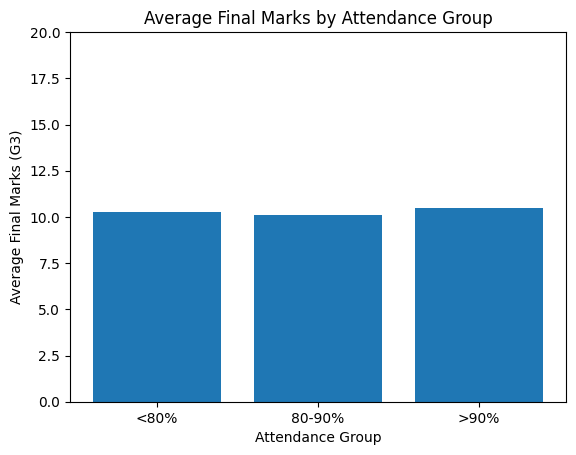

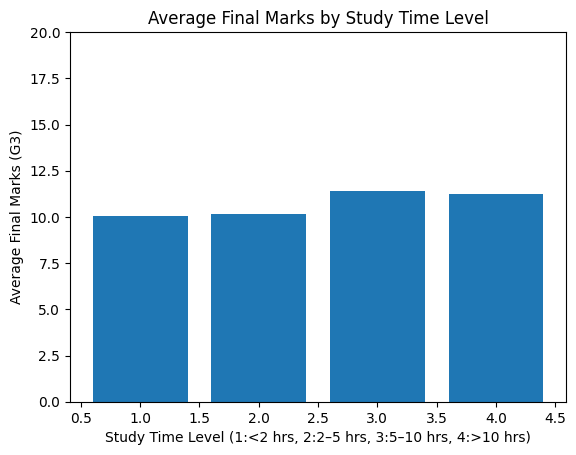

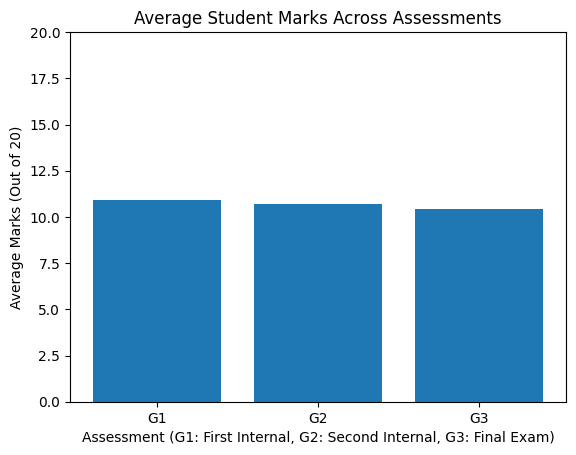

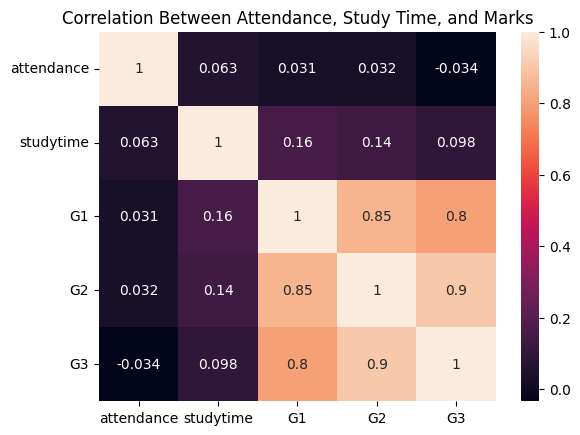

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create attendance from absences
data['attendance'] = 100 - data['absences']

# Create attendance groups
bins = [0, 80, 90, 101]
labels = ['<80%', '80-90%', '>90%']
data['attendance_group'] = pd.cut(data['attendance'], bins=bins, labels=labels, right=False)

# Select required columns only
eda_data = data[['attendance', 'studytime', 'G1', 'G2', 'G3']]

# Show basic statistics
print(eda_data.describe())

# -----------------------------
# Attendance distribution
# -----------------------------
attendance_perf = data.groupby('attendance_group', observed=True)['G3'].mean()

plt.figure()
plt.bar(attendance_perf.index, attendance_perf.values)
plt.xlabel("Attendance Group")
plt.ylabel("Average Final Marks (G3)")
plt.title("Average Final Marks by Attendance Group")
plt.ylim(0, 20)
plt.xticks(rotation=0)

plt.show()


# -----------------------------
# Study time distribution
# -----------------------------
study_perf = data.groupby('studytime')['G3'].mean()

plt.figure()
plt.bar(study_perf.index, study_perf.values)
plt.xlabel("Study Time Level (1:<2 hrs, 2:2–5 hrs, 3:5–10 hrs, 4:>10 hrs)")
plt.ylabel("Average Final Marks (G3)")
plt.title("Average Final Marks by Study Time Level")
plt.ylim(0, 20)
plt.show()


# -----------------------------
# Average marks
# -----------------------------
avg_scores = eda_data[['G1', 'G2', 'G3']].mean()

plt.figure()
plt.bar(avg_scores.index, avg_scores.values)
plt.xlabel("Assessment (G1: First Internal, G2: Second Internal, G3: Final Exam)")
plt.ylabel("Average Marks (Out of 20)")
plt.title("Average Student Marks Across Assessments")
plt.ylim(0, 20)
plt.show()

# -----------------------------
# Correlation heatmap
# -----------------------------
plt.figure()
sns.heatmap(eda_data.corr(), annot=True)
plt.title("Correlation Between Attendance, Study Time, and Marks")
plt.show()


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Select features and target
X = data[['studytime', 'attendance', 'G1', 'G2']]
y = data['G3']

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate model
print("Model Accuracy (R2 score):", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))

Model Accuracy (R2 score): 0.8470256862898013
Mean Absolute Error: 1.0452298638783348
